In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("titanic_train.csv")
test_data = pd.read_csv("titanic_test.csv")

passenger_id = test_data["PassengerId"]

train_data.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
279,280,1,3,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0,1,1,C.A. 2673,20.2500,NaN,S
788,789,1,3,"Dean, Master. Bertram Vere",male,1.0,1,2,C.A. 2315,20.5750,NaN,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
398,399,0,2,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,NaN,S
568,569,0,3,"Doharr, Mr. Tannous",male,NaN,0,0,2686,7.2292,NaN,C


In [45]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [46]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [47]:
train_y = train_data["Survived"]
train_X = train_data.drop(columns = ["Survived","PassengerId","Name"])
test_X = test_data.drop(columns = ["PassengerId","Name"])

X = pd.concat([train_X, test_X], axis = 0).reset_index()

In [48]:
X.describe()

,index,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,369.478992,2.294882,29.881138,0.498854,0.385027,33.295479
std,248.767105,0.837836,14.413493,1.041658,0.865560,51.758668
min,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,163.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,327.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,563.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,890.000000,3.000000,80.000000,8.000000,9.000000,512.329200


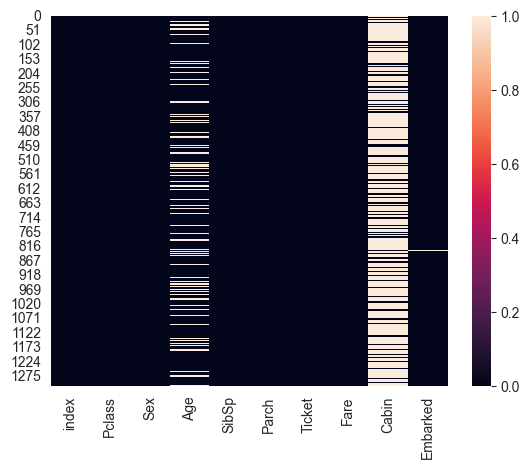

index       0.000000
Pclass      0.000000
Sex         0.000000
Age         0.200917
SibSp       0.000000
Parch       0.000000
Ticket      0.000000
Fare        0.000764
Cabin       0.774637
Embarked    0.001528
dtype: float64

In [49]:
sns.heatmap(X.isna())
plt.show()
X.isna().sum()/1309

In [50]:
print(X["Age"].index, len(X["Age"].index))

RangeIndex(start=0, stop=1309, step=1) 1309


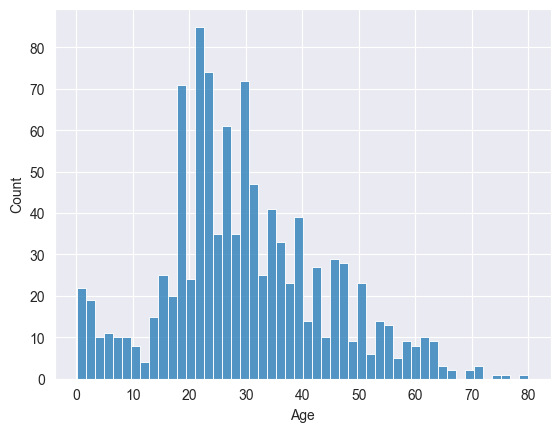

In [51]:
sns.histplot(x = "Age", data = X,bins = 50)
plt.show()

In [52]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode())
X["Cabin"] = X["Cabin"].fillna("missing")

In [53]:
from scipy import stats

transformed_data, lambda_value = stats.boxcox(X['Age'])

In [54]:
X["Age"] = transformed_data

In [55]:
cat_cols = X.select_dtypes(include = "object").columns
for cat in cat_cols:
    dummies = pd.get_dummies(X[cat], prefix=cat)
    X = pd.concat([X, dummies], axis = 1)
    X = X.drop(columns = cat)

In [56]:
X_train = X[:len(train_X.index)]
X_test = X[len(train_X.index):]


In [57]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, train_y)
y_pred = model.predict(X_test)

In [58]:
df = pd.DataFrame({"PassengerId":passenger_id, "Survived":y_pred})
df.to_csv("titanic_pred.csv", index=False,columns = ["PassengerId", "Survived"])